In [ ]:
# Install the decoders needed for JPEG Lossless DICOMs
!pip install -qU pylibjpeg pylibjpeg-libjpeg pydicom python-gdcm

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pydicom
import os
import glob

# Set plot style
sns.set_theme(style="whitegrid")

# **Load the Dataset**
We'll use the path shown in your sidebar to read the CSV files into Pandas DataFrames.

In [3]:
import pandas as pd
import os

# Updated path based on your screenshots
BASE_PATH = "/kaggle/input/competitions/rsna-breast-cancer-detection"

# Loading the CSV files
train_df = pd.read_csv(f"{BASE_PATH}/train.csv")
test_df = pd.read_csv(f"{BASE_PATH}/test.csv")

print("Data loaded successfully!")
print(f"Dataset contains {train_df.shape[0]} training records.")

Data loaded successfully!
Dataset contains 54706 training records.


# **Basic Exploration (Pandas Functions)**
Let's take a quick look at the structure of this new dataset using simple functions.

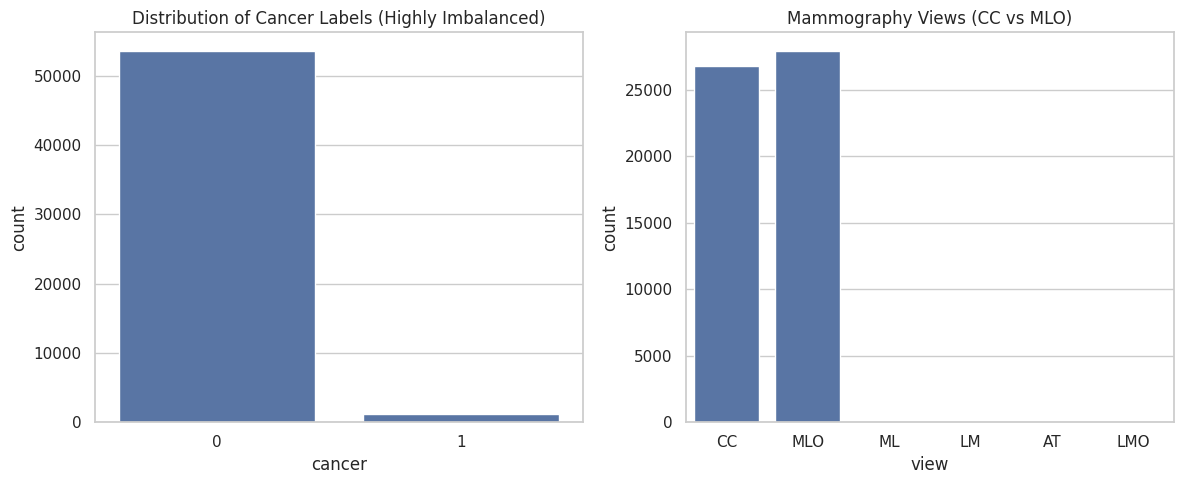

Missing values in train:
site_id                        0
patient_id                     0
image_id                       0
laterality                     0
view                           0
age                           37
cancer                         0
biopsy                         0
invasive                       0
BIRADS                     28420
implant                        0
density                    25236
machine_id                     0
difficult_negative_case        0
dtype: int64


In [4]:
plt.figure(figsize=(12, 5))

# Plot 1: Target Distribution
plt.subplot(1, 2, 1)
sns.countplot(data=train_df, x='cancer')
plt.title('Distribution of Cancer Labels (Highly Imbalanced)')

# Plot 2: View Distribution
plt.subplot(1, 2, 2)
sns.countplot(data=train_df, x='view')
plt.title('Mammography Views (CC vs MLO)')

plt.tight_layout()
plt.show()

# Check for missing values
print("Missing values in train:")
print(train_df.isnull().sum())

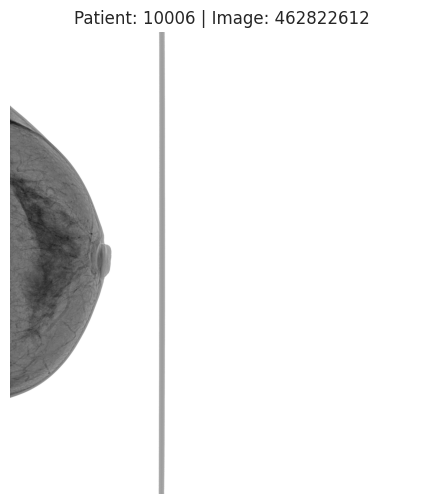

In [5]:
def show_image(patient_id, image_id):
    path = f"{BASE_PATH}/train_images/{patient_id}/{image_id}.dcm"
    dicom = pydicom.dcmread(path)
    
    # Extract pixel data
    img = dicom.pixel_array
    
    plt.figure(figsize=(6, 6))
    plt.imshow(img, cmap='gray')
    plt.title(f"Patient: {patient_id} | Image: {image_id}")
    plt.axis('off')
    plt.show()

# Example visualization using the first row
sample_row = train_df.iloc[0]
show_image(sample_row['patient_id'], sample_row['image_id'])

# **Exploratory Data Analysis (EDA)**
In this competition, the primary goal is to detect cancer. Let's see how the labels are distributed.

RuntimeError: Unable to decompress 'JPEG Lossless, Non-Hierarchical, First-Order Prediction (Process 14 [Selection Value 1])' pixel data because all plugins are missing dependencies:
	gdcm - requires gdcm>=3.0.10
	pylibjpeg - requires pylibjpeg>=2.0 and pylibjpeg-libjpeg>=2.1

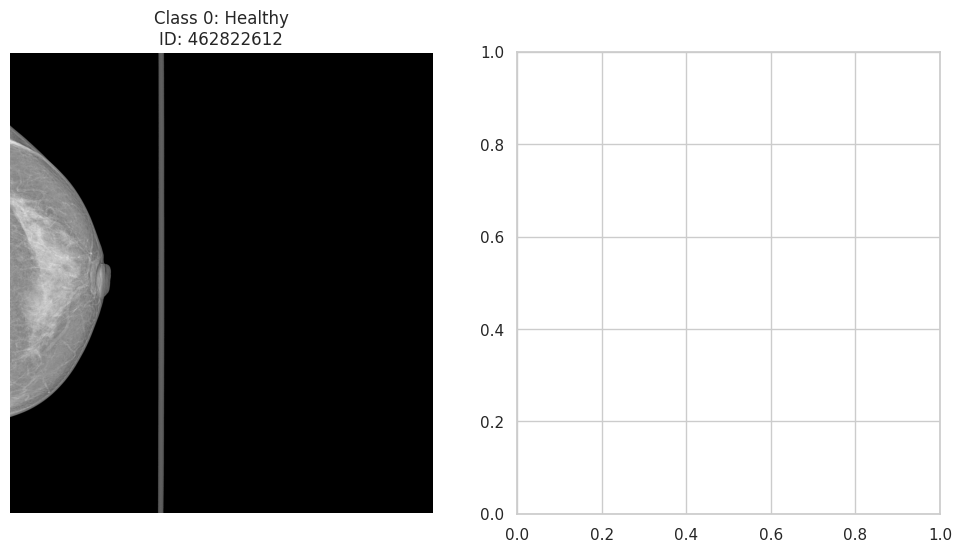

In [6]:
import pydicom
import matplotlib.pyplot as plt
import os

def get_processed_pixels(case):
    path = f"{BASE_PATH}/train_images/{case['patient_id']}/{case['image_id']}.dcm"
    dicom = pydicom.dcmread(path)
    
    # This will now work after the pip install and restart
    img = dicom.pixel_array
    
    # Fix for inverted images (some images have MONOCHROME1 interpretation)
    if dicom.PhotometricInterpretation == "MONOCHROME1":
        img = img.max() - img
        
    return img

# Get examples of both classes
normal_case = train_df[train_df['cancer'] == 0].iloc[0]
cancer_case = train_df[train_df['cancer'] == 1].iloc[0]

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(get_processed_pixels(normal_case), cmap='gray')
axes[0].set_title(f"Class 0: Healthy\nID: {normal_case['image_id']}")
axes[0].axis('off')

axes[1].imshow(get_processed_pixels(cancer_case), cmap='gray')
axes[1].set_title(f"Class 1: Cancer\nID: {cancer_case['image_id']}")
axes[1].axis('off')

plt.tight_layout()
plt.show()

## **Distribution of Cancer across Age**
Since you have a background in data analysis, visualizing the age distribution helps confirm if the data matches clinical expectations (e.g., higher risk with age).

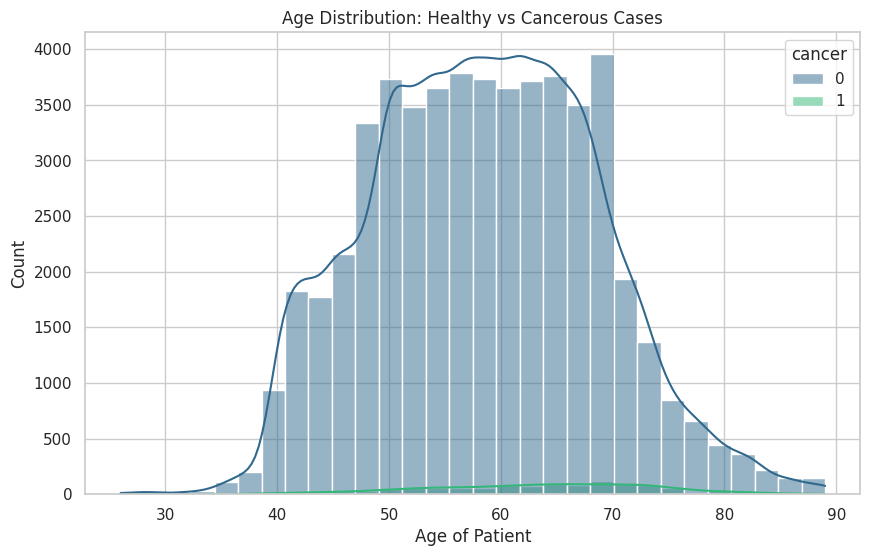

In [7]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(data=train_df, x='age', hue='cancer', kde=True, bins=30, palette='viridis')
plt.title('Age Distribution: Healthy vs Cancerous Cases')
plt.xlabel('Age of Patient')
plt.ylabel('Count')
plt.show()

## **Analysis of Mammography "Views"**
Mammograms are taken from different angles, mainly CC (Craniocaudal) and MLO (Mediolateral Oblique). A healthy patient should have both.

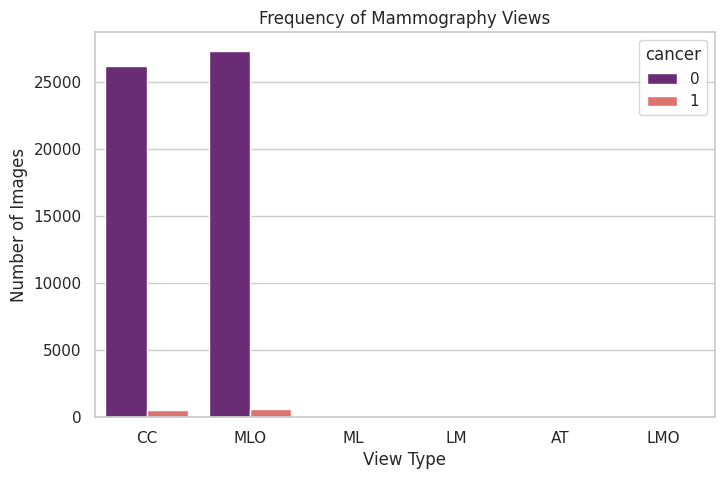

In [8]:
plt.figure(figsize=(8, 5))
sns.countplot(data=train_df, x='view', hue='cancer', palette='magma')
plt.title('Frequency of Mammography Views')
plt.xlabel('View Type')
plt.ylabel('Number of Images')
plt.show()

## **Imaging Laterality (Left vs Right)**
Check if cancer is more prevalent in one breast or if the data is symmetric.

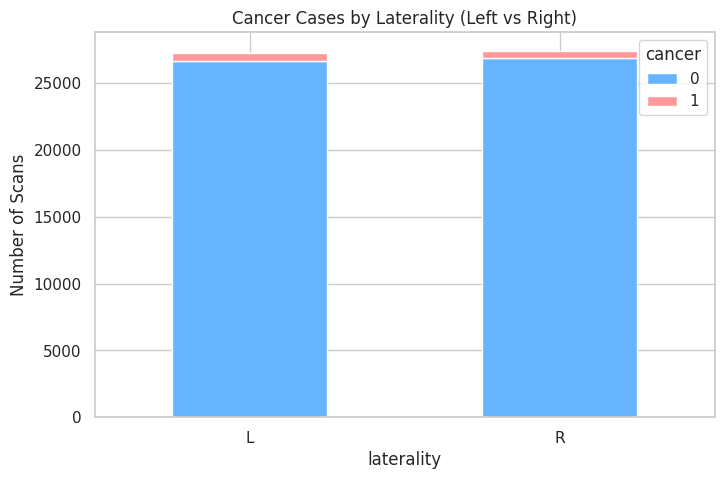

In [9]:
# Grouping data to see if cancer is breast-specific
laterality_stats = train_df.groupby(['laterality', 'cancer']).size().unstack()

laterality_stats.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#66b3ff','#ff9999'])
plt.title('Cancer Cases by Laterality (Left vs Right)')
plt.ylabel('Number of Scans')
plt.xticks(rotation=0)
plt.show()

## **Identifying Imbalance: The "Pie" Check**
In medical AI, the Class Imbalance is your biggest enemy.

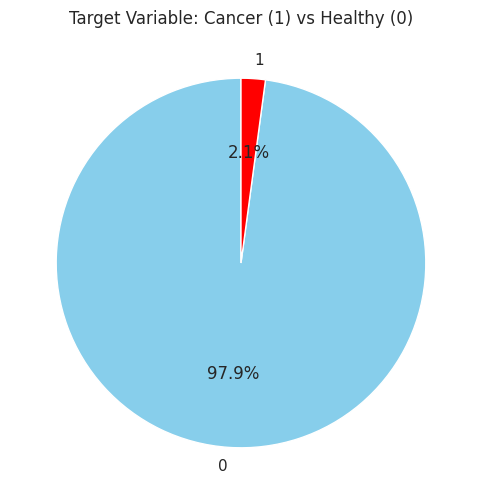

In [10]:
plt.figure(figsize=(6, 6))
train_df['cancer'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, colors=['skyblue', 'red'])
plt.title('Target Variable: Cancer (1) vs Healthy (0)')
plt.ylabel('') # Hides the 'cancer' label on the side
plt.show()

In [11]:
import os

# Create a full path column for easier access during training
def get_image_path(row):
    return os.path.join(BASE_PATH, "train_images", str(row['patient_id']), f"{row['image_id']}.dcm")

train_df['file_path'] = train_df.apply(get_image_path, axis=1)

# Display to verify
print("New file_path column added:")
display(train_df[['patient_id', 'image_id', 'file_path', 'cancer']].head())

New file_path column added:


,patient_id,image_id,file_path,cancer
0,10006,462822612,/kaggle/input/competitions/rsna-breast-cancer-...,0
1,10006,1459541791,/kaggle/input/competitions/rsna-breast-cancer-...,0
2,10006,1864590858,/kaggle/input/competitions/rsna-breast-cancer-...,0
3,10006,1874946579,/kaggle/input/competitions/rsna-breast-cancer-...,0
4,10011,220375232,/kaggle/input/competitions/rsna-breast-cancer-...,0


# **Stratified Train-Validation Split**
In medical datasets where the positive class is rare (e.g., only 2% have cancer), a random split might result in a validation set with zero cancer cases. Stratified splitting ensures the percentage of cancer cases is the same in both the training and validation sets.

In [12]:
from sklearn.model_selection import train_test_split

# We split by 'cancer' to maintain class proportions
train_split, val_split = train_test_split(
    train_df, 
    test_size=0.2, 
    stratify=train_df['cancer'], 
    random_state=42
)

print(f"Total Images: {len(train_df)}")
print(f"Training set: {len(train_split)} (Cancer rate: {train_split.cancer.mean():.2%})")
print(f"Validation set: {len(val_split)} (Cancer rate: {val_split.cancer.mean():.2%})")

Total Images: 54706
Training set: 43764 (Cancer rate: 2.12%)
Validation set: 10942 (Cancer rate: 2.12%)


In [15]:
# Separate classes
df_healthy = train_split[train_split['cancer'] == 0]
df_cancer = train_split[train_split['cancer'] == 1]

# Oversample the minority class (cancer)
df_cancer_upsampled = df_cancer.sample(len(df_healthy), replace=True, random_state=42)

# Combine back into a balanced training set
train_balanced = pd.concat([df_healthy, df_cancer_upsampled])

print("Balanced Training Set Distribution:")
print(train_balanced['cancer'].value_counts())

Balanced Training Set Distribution:
cancer
0    42838
1    42838
Name: count, dtype: int64


# **The Preprocessing Function**
We need a helper function that TensorFlow can call to convert the DICOM file path into a usable numerical tensor.

In [16]:
import tensorflow as tf
import pydicom
import numpy as np

def load_dicom_image(path):
    # Decode the path from tensor to string
    path = path.numpy().decode('utf-8')
    dicom = pydicom.dcmread(path)
    img = dicom.pixel_array.astype(np.float32)
    
    # Standardize Photometric Interpretation
    if dicom.PhotometricInterpretation == "MONOCHROME1":
        img = np.max(img) - img
        
    # Normalize to [0, 1] and resize for the model
    img = (img - np.min(img)) / (np.max(img) - np.min(img) + 1e-6)
    img = tf.image.resize(img[..., np.newaxis], (224, 224))
    return img

# Wrap the python function for TensorFlow
def tf_load_image(path, label):
    [img,] = tf.py_function(load_dicom_image, [path], [tf.float32])
    img.set_shape((224, 224, 1))
    return img, label

2026-02-26 16:08:44.786377: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772122125.226796      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772122125.361287      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772122126.394815      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772122126.394869      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772122126.394872      55 computation_placer.cc:177] computation placer alr

# **Creating the TensorFlow Data Pipeline**
We use the structured DataFrames we created earlier (train_split and val_split) to feed the model. We'll use a small batch size because DICOM images are memory-intensive.

In [18]:
BATCH_SIZE = 16

def prepare_dataset(df):
    ds = tf.data.Dataset.from_tensor_slices((df['file_path'].values, df['cancer'].values))
    ds = ds.map(tf_load_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = prepare_dataset(train_split) # Or use train_balanced from the previous step
val_ds = prepare_dataset(val_split)

# **MobileNetV2**

## **Building the Model Architecture**
In this cell, we define a Convolutional Neural Network (CNN) using Transfer Learning. We use the MobileNetV2 architecture because it is lightweight and efficient for Kaggle’s T4 GPUs.

In [19]:
from tensorflow.keras import layers, models

def build_mammography_model():
    # 1. Base Model: Pre-trained on ImageNet
    # We include_top=False to remove the final classification layer
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(224, 224, 3), 
        include_top=False, 
        weights='imagenet'
    )
    
    # Freeze the base model to preserve pre-trained features
    base_model.trainable = False 

    # 2. Model Structure
    model = models.Sequential([
        # Input layer for 1-channel grayscale mammograms
        layers.Input(shape=(224, 224, 1)),
        
        # Convert 1-channel to 3-channels so it can pass through MobileNetV2
        layers.Conv2D(3, (3, 3), padding='same'), 
        
        base_model,
        
        # Global Pooling reduces the spatial dimensions (7x7) to a single vector
        layers.GlobalAveragePooling2D(),
        
        # Dense layers for final classification
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3), # Dropout prevents overfitting
        layers.Dense(1, activation='sigmoid') # Sigmoid for binary cancer detection
    ])
    
    # 3. Compilation
    # We use AUC instead of Accuracy because the dataset is highly imbalanced
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC(name='auc'), 'accuracy']
    )
    
    return model

# Initialize the model
model = build_mammography_model()
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 3)    │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,111 (9.24 MB)

 Trainable params: 164,127 (641.12 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## **Taining the Model**
This cell starts the actual training process. We use the train_ds and val_ds created in your previous step.

In [1]:
# Define how many epochs to run (start small to test)
EPOCHS = 5

# Start Training
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    verbose=1
)

NameError: name 'model' is not defined

## **Visualizing Performance**
Once training finishes, we need to plot the results to see if the AUC improved over time.

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    
    # Plot AUC
    ax[0].plot(history.history['auc'], label='Train AUC')
    ax[0].plot(history.history['val_auc'], label='Val AUC')
    ax[0].set_title('Model AUC')
    ax[0].legend()
    
    # Plot Loss
    ax[1].plot(history.history['loss'], label='Train Loss')
    ax[1].plot(history.history['val_loss'], label='Val Loss')
    ax[1].set_title('Model Loss')
    ax[1].legend()
    
    plt.show()

plot_history(history)

## **Generating Predictions and Classification Report**
In this cell, we collect the predictions from the validation set. Since the output of the model is a probability (via the sigmoid activation), we convert anything above 0.5 to a class 1 (Cancer) and anything below to class 0 (Healthy).

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# 1. Get true labels and predictions from the validation dataset
y_true = []
y_probs = []

# Loop through the validation dataset to gather labels and model predictions
for imgs, labels in val_ds:
    preds = model.predict(imgs, verbose=0)
    y_probs.extend(preds.flatten())
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_probs = np.array(y_probs)
y_pred = (y_probs > 0.5).astype(int)

# 2. Print Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Healthy', 'Cancer']))

## **Plotting the Confusion Matrix and ROC Curve**
These visualizations help you see where the model is getting confused—for example, if it is incorrectly labeling healthy tissue as potentially cancerous.

In [ ]:
import seaborn as sns

def plot_evaluation_charts(y_true, y_probs, y_pred):
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))

    # --- 1. Confusion Matrix ---
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
    ax[0].set_title('Confusion Matrix')
    ax[0].set_xlabel('Predicted Label')
    ax[0].set_ylabel('True Label')

    # --- 2. ROC Curve ---
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)
    
    ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax[1].set_xlim([0.0, 1.0])
    ax[1].set_ylim([0.0, 1.05])
    ax[1].set_xlabel('False Positive Rate (1 - Specificity)')
    ax[1].set_ylabel('True Positive Rate (Sensitivity)')
    ax[1].set_title('Receiver Operating Characteristic (ROC)')
    ax[1].legend(loc="lower right")

    plt.tight_layout()
    plt.show()

plot_evaluation_charts(y_true, y_probs, y_pred)